In [3]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv('D:\Download\Data Analyst course/bepec\ML_stat\Auto_price\Automobile price data _Raw.csv')

In [5]:
df.replace('?', pd.NA, inplace=True)

In [6]:
df=df.dropna()

In [7]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [8]:
numeric_cols_with_issues = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']

for col in numeric_cols_with_issues:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [9]:
df.dtypes

symboling              int64
normalized-losses      int64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

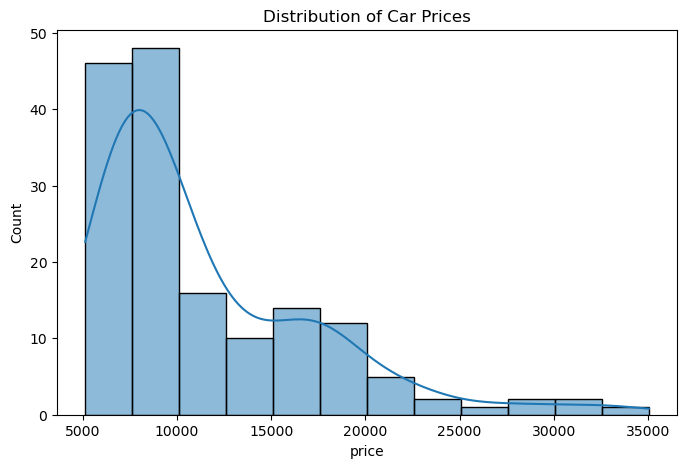

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Car Prices')
plt.show()

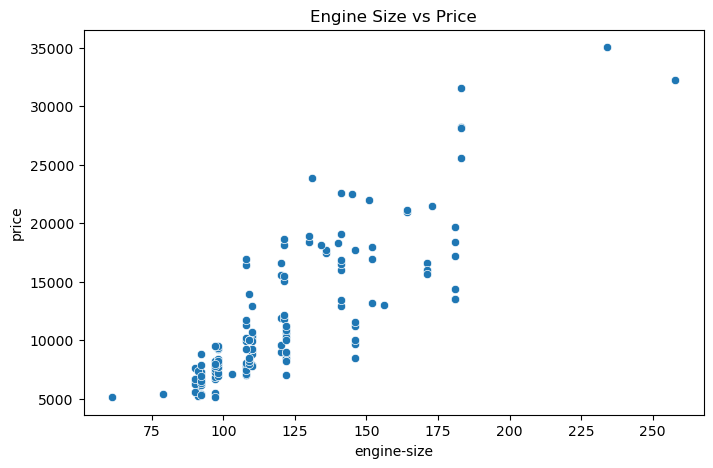

In [11]:
# Scatter plot for Engine Size vs Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x='engine-size', y='price', data=df)
plt.title('Engine Size vs Price')
plt.show()

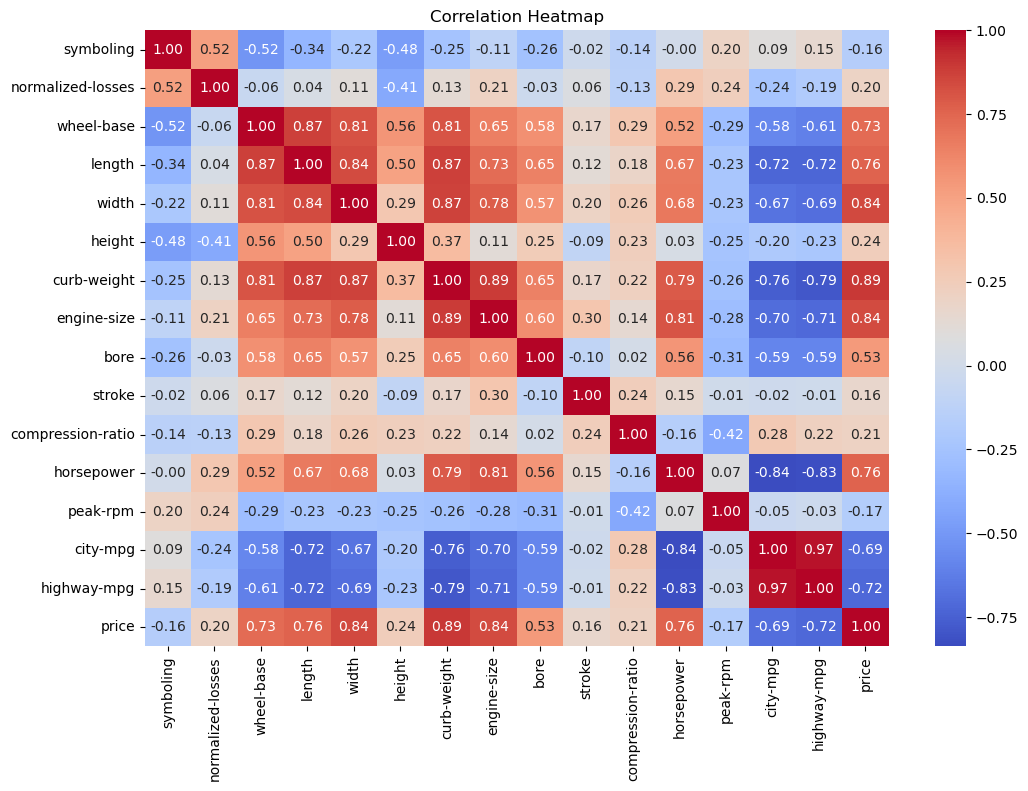

In [12]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [13]:
x=df.iloc[:,:25]

In [14]:
y=df.iloc[:,25:]

In [15]:
cat_col=x.select_dtypes(include=['object']).columns

In [16]:
x_encode=pd.get_dummies(x, columns=cat_col, drop_first=True)

In [17]:
print(f"Original features: {x.shape[1]}")
print(f"Encoded features: {x_encode.shape[1]}")

Original features: 25
Encoded features: 54


In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_encode, y, test_size=0.2, random_state=42)

In [19]:
print(f"Training data size: {x_train.shape[0]} rows")
print(f"Testing data size: {x_test.shape[0]} rows")

Training data size: 127 rows
Testing data size: 32 rows


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [21]:
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
lr_preds = lr_model.predict(x_test)

In [22]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(x_train, y_train)
rf_preds = rf_model.predict(x_test)

c:\Users\arunk\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [23]:
rf_train_preds = rf_model.predict(x_train)
lr_train_preds = lr_model.predict(x_train)

In [24]:
print(f"Training R-squared rf: {r2_score(y_train, rf_train_preds):.2f}")
print(f"Training R-squared lr: {r2_score(y_train, lr_train_preds):.2f}")

Training R-squared rf: 0.98
Training R-squared lr: 0.98


In [25]:
print("--- Linear Regression ---")
print(f"R-squared: {r2_score(y_test, lr_preds):.2f}")
print(f"MAE: ${mean_absolute_error(y_test, lr_preds):.2f}")

print("\n--- Random Forest ---")
print(f"R-squared: {r2_score(y_test, rf_preds):.2f}")
print(f"MAE: ${mean_absolute_error(y_test, rf_preds):.2f}")

--- Linear Regression ---
R-squared: 0.81
MAE: $1429.75

--- Random Forest ---
R-squared: 0.84
MAE: $1297.79


In [26]:
from sklearn.model_selection import GridSearchCV

In [27]:
param_grid = {
    'n_estimators': [50, 100, 200],    
    'max_depth': [5, 10, None],         
    'min_samples_split': [2, 5, 10],     
    'min_samples_leaf': [1, 2, 4]
}

In [28]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3, 
    n_jobs=-1, # Uses all your CPU cores to run faster!
    scoring='r2'
)

In [29]:
grid_search.fit(x_train, y_train.values.ravel())

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [30]:
best_rf = grid_search.best_estimator_

In [31]:
tuned_train_preds = best_rf.predict(x_train)
tuned_test_preds = best_rf.predict(x_test)

In [32]:
print(f"Tuned Training R-squared: {r2_score(y_train, tuned_train_preds):.2f}")
print(f"Tuned Testing R-squared: {r2_score(y_test, tuned_test_preds):.2f}")
print(f"Best Parameters: {grid_search.best_params_}")

Tuned Training R-squared: 0.96
Tuned Testing R-squared: 0.82
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}


In [33]:
importances = best_rf.feature_importances_
feature_names = x_train.columns

In [34]:
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

In [47]:
top_10_features = importance_df.sort_values(by='Importance', ascending=False).head(15)
print(top_10_features)

               Feature  Importance
6          curb-weight    0.494428
7          engine-size    0.188877
4                width    0.079314
2           wheel-base    0.045954
13            city-mpg    0.037770
14         highway-mpg    0.029892
1    normalized-losses    0.020994
3               length    0.014972
40    drive-wheels_rwd    0.013749
9               stroke    0.011919
21  make_mercedes-benz    0.011711
11          horsepower    0.010964
10   compression-ratio    0.005963
5               height    0.005311
33    aspiration_turbo    0.004015


C:\Users\arunk\AppData\Local\Temp\ipykernel_18652\3733632073.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


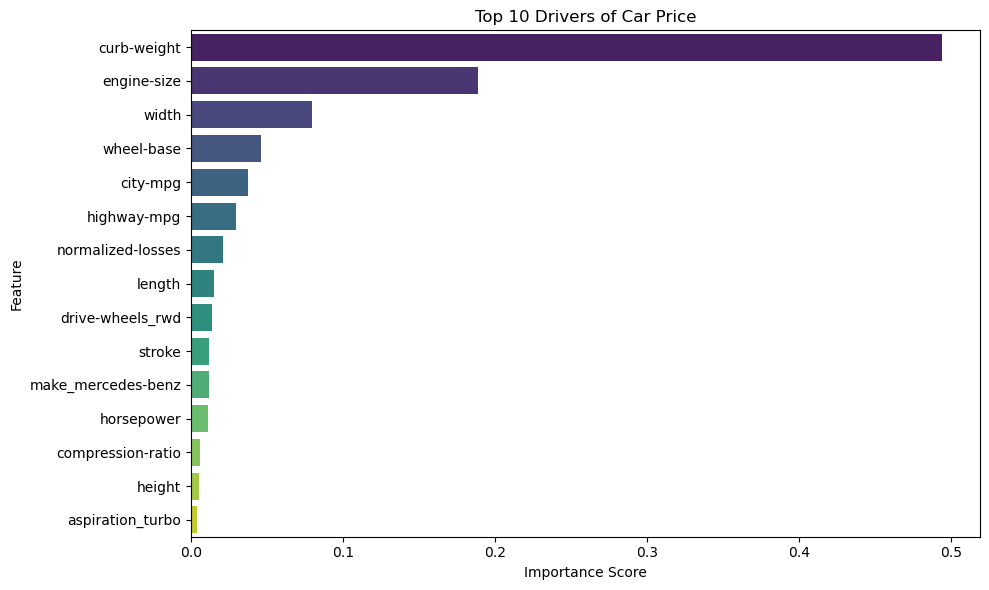

In [46]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title('Top 10 Drivers of Car Price')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [37]:
import joblib

In [38]:
joblib.dump(best_rf, 'auto_price_model.pkl')

['auto_price_model.pkl']

In [39]:
model_columns=list(x_train.columns)
joblib.dump(model_columns, 'model_columns.pkl')

['model_columns.pkl']

In [42]:
import shap

In [43]:
explainer=shap.TreeExplainer(best_rf)

In [44]:
joblib.dump(explainer, 'shap_explainer.pkl')

['shap_explainer.pkl']

In [68]:
v2_features = (['make', 'city-mpg', 'highway-mpg','engine-size', 'curb-weight', 'width', 'wheel-base'])

In [69]:
# cat_col=v2_features.select_dtypes(include=['object']).columns

In [70]:
X_v2 = df[v2_features]
y_v2 = df['price']

In [71]:
cat_cols=['make']

In [72]:
X_v2_encoded=pd.get_dummies(X_v2, columns=cat_cols, drop_first=True)

In [73]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2_encoded, y_v2, test_size=0.2, random_state=42
)

In [74]:
rf_v2 = RandomForestRegressor(
    n_estimators=50, 
    max_depth=10, 
    min_samples_split=2, 
    min_samples_leaf=2, 
    random_state=42
)

In [75]:
rf_v2.fit(X_train_v2, y_train_v2.values.ravel())

,n_estimators,50
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
v2_preds = rf_v2.predict(X_test_v2)
print(f"Version 2 Testing R-squared: {r2_score(y_test_v2, v2_preds):.2f}")
print(f"Version 2 MAE: ${mean_absolute_error(y_test_v2, v2_preds):.2f}")

Version 2 Testing R-squared: 0.82
Version 2 MAE: $1314.48


In [77]:
v2_tr_preds = rf_v2.predict(X_train_v2)
print(f"Version 2 Testing R-squared: {r2_score(y_train_v2, v2_tr_preds):.2f}")
print(f"Version 2 MAE: ${mean_absolute_error(y_train_v2, v2_tr_preds):.2f}")

Version 2 Testing R-squared: 0.97
Version 2 MAE: $728.41


In [80]:
joblib.dump(rf_v2, 'auto_price_v2_model.pkl')
joblib.dump(list(X_train_v2.columns), 'v2_model_columns.pkl')

['v2_model_columns.pkl']

In [83]:
explainer_v2 = shap.TreeExplainer(rf_v2)

In [84]:
joblib.dump(explainer_v2, 'shap_explainer_v2.pkl')

['shap_explainer_v2.pkl']